In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Orders Exploration

In [2]:
df_orders = pd.read_csv('../data/orders.csv')

In [3]:
df_orders.shape

(32313, 8)

In [4]:
df_orders.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [5]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  str    
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), str(1)
memory usage: 2.0 MB


In [6]:
df_orders.isna().sum()

order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

In [7]:
df_orders['created_at'] = pd.to_datetime(df_orders['created_at'])

In [8]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            32313 non-null  int64         
 1   created_at          32313 non-null  datetime64[us]
 2   website_session_id  32313 non-null  int64         
 3   user_id             32313 non-null  int64         
 4   primary_product_id  32313 non-null  int64         
 5   items_purchased     32313 non-null  int64         
 6   price_usd           32313 non-null  float64       
 7   cogs_usd            32313 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(5)
memory usage: 2.0 MB


In [9]:
df_orders['order_id'].nunique()

32313

In [10]:
df_orders['user_id'].nunique()

31696

In [11]:
df_orders['order_id'].nunique() - df_orders['user_id'].nunique()

617

In [12]:
df_orders[['items_purchased', 'price_usd', 'cogs_usd']].describe()

,items_purchased,price_usd,cogs_usd
count,32313.000000,32313.000000,32313.000000
mean,1.238666,59.991636,22.355406
std,0.426274,17.808771,6.238621
min,1.000000,29.990000,9.490000
25%,1.000000,49.990000,19.490000
50%,1.000000,49.990000,19.490000
75%,1.000000,59.990000,22.490000
max,2.000000,109.980000,41.980000


In [13]:
df_orders['created_at'].describe()

count                         32313
mean     2014-04-14 03:01:01.276823
min             2012-03-19 10:42:46
25%             2013-10-30 14:30:35
50%             2014-06-11 14:27:02
75%             2014-11-28 10:53:48
max             2015-03-19 05:38:31
Name: created_at, dtype: object

In [14]:
df_orders['created_at'].dt.year.value_counts()

created_at
2014    16860
2013     7447
2015     5420
2012     2586
Name: count, dtype: int64

In [15]:
df_orders['created_at'].dt.month.value_counts()

created_at
12    3867
2     3587
1     3470
11    3464
3     2765
10    2688
9     2340
8     2161
7     2059
5     2047
6     1972
4     1893
Name: count, dtype: int64

In [16]:
df_orders['website_session_id'].nunique()

32313

In [17]:
df_orders['primary_product_id'].value_counts()

primary_product_id
1    23861
2     4803
3     3068
4      581
Name: count, dtype: int64

### Column Insights
##### Order ID
- There are 32,313 orders
- Each row corresponds to a single order
##### Created At
- The earliest order was on March 19th, 2012, 10:42 AM
- The most recent order was on March 19th, 2015, 5:38 AM
- Most orders were in 2014, and the fewest orders were in 2012.
- The most common months orders were placed in were November - Feburary.
##### Website Session ID
- There are 32,313 session IDs
- Each row corresponds to a single session
##### User ID
- There are 31,696 unique customers
- 32,313 - 31,696 is 617, so 617 customers have multiple orders
##### Primary Product ID
- This column corresponds to the products table.
- The most commonly purchased item is with product ID 1.
    - Product ID 4 is the least commonly ordered.
##### Items Purchased
- The most items a user purchased in a single order is 2.
- More commonly, customers would only purchase one item.
##### Price USD
- The average price of an order was around 60 USD.
- The median price is around 50 USD, signifying that the distribution is right-skewed.
- The lowest price of an order was 30 USD and the highest was 110 USD
##### COGS USD (Cost of Goods Sold)
- The average COGS of an order was around 22.35 USD.
- The median COGS is around 19.49 USD, signifying that the distribution is slightly right-skewed.
- The lowest COGS of an order was 9.49 USD and the highest was 41.98 USD

<Axes: xlabel='price_usd', ylabel='Count'>

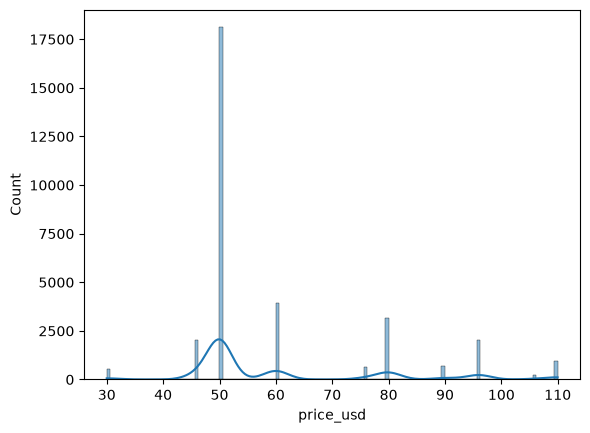

In [18]:
sns.histplot(data=df_orders['price_usd'], kde=True)

<Axes: ylabel='price_usd'>

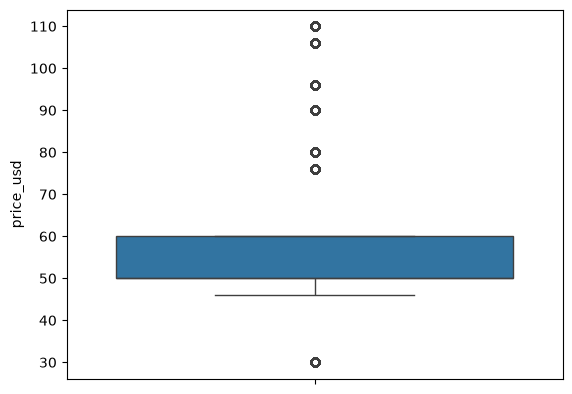

In [19]:
sns.boxplot(data=df_orders['price_usd'])

In [20]:
df_orders['items_purchased'].value_counts()

items_purchased
1    24601
2     7712
Name: count, dtype: int64

In [21]:
df_orders['items_purchased'].value_counts(normalize=True)

items_purchased
1    0.761334
2    0.238666
Name: proportion, dtype: float64

## Order Items Exploration

In [22]:
df_order_items = pd.read_csv('../data/order_items.csv')

In [23]:
df_order_items.shape

(40025, 7)

In [24]:
df_order_items.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [52]:
df_order_items['is_primary_item'].value_counts()

is_primary_item
1    32313
0     7712
Name: count, dtype: int64

In [25]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  str    
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), str(1)
memory usage: 2.1 MB


In [26]:
df_order_items.isna().sum()

order_item_id      0
created_at         0
order_id           0
product_id         0
is_primary_item    0
price_usd          0
cogs_usd           0
dtype: int64

In [27]:
df_order_items['created_at'] = pd.to_datetime(df_order_items['created_at'])

In [28]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_item_id    40025 non-null  int64         
 1   created_at       40025 non-null  datetime64[us]
 2   order_id         40025 non-null  int64         
 3   product_id       40025 non-null  int64         
 4   is_primary_item  40025 non-null  int64         
 5   price_usd        40025 non-null  float64       
 6   cogs_usd         40025 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(4)
memory usage: 2.1 MB


In [49]:
df_order_items['created_at'].describe()

count                         40025
mean     2014-05-13 10:24:45.947732
min             2012-03-19 10:42:46
25%             2013-12-25 23:27:19
50%             2014-07-14 15:31:31
75%             2014-12-01 16:41:10
max             2015-03-19 05:38:31
Name: created_at, dtype: object

In [50]:
df_order_items['created_at'].dt.year.value_counts()

created_at
2014    22581
2013     7613
2015     7245
2012     2586
Name: count, dtype: int64

In [51]:
df_order_items['created_at'].dt.month.value_counts()

created_at
12    4744
2     4552
1     4347
11    4218
3     3565
10    3311
9     2873
8     2628
5     2552
7     2518
6     2408
4     2309
Name: count, dtype: int64

In [55]:
df_order_items[['price_usd', 'cogs_usd']].describe()

,price_usd,cogs_usd
count,40025.000000,40025.000000
mean,48.432473,18.047976
std,8.012370,3.856821
min,29.990000,9.490000
25%,49.990000,19.490000
50%,49.990000,19.490000
75%,49.990000,19.490000
max,59.990000,22.490000


### Column Insights

##### order item id
- unique identifier of the order item

##### created at
- earliest created at timestamp is on March 19th, 2012
- the most recent created at timestamp is on March 19th, 2015
- like the orders table, the most created at timestamps are in 2014, and the least are in 2012
- Most common months of created at are from Novemeber - Feburary

##### order id
- foreign key to the orders table

##### product id
- foreign key to the products table

##### is primary item
- integer column, but represents boolean.
- signifyies if the product of the order item is the primary or secondary product.

##### price usd
- price of the order item (may be multiple for an order)
- average price of an order item: 48.43
- median price of an order item: 49.99.
- distribution does not seem to be skewed, as the mean and median are similar.

##### cogs usd
- cogs of the order item (may be multiple for an order)
- the average cogs for an order item is 18.05 USD
- the median cogs for an order item is 19.49
- distribution does not seem to be skewed, as the mean and median are similar.



In [48]:
df_order_items['order_item_id'].nunique()

40025

In [54]:
df_order_items['order_id'].value_counts()

order_id
7300     2
7302     2
7310     2
7352     2
7376     2
        ..
32308    1
32309    1
32310    1
32312    1
32313    1
Name: count, Length: 32313, dtype: int64

In [61]:
df_order_items['price_usd'].value_counts()

price_usd
49.99    24226
59.99     5796
29.99     5018
45.99     4985
Name: count, dtype: int64

<Axes: xlabel='price_usd', ylabel='Count'>

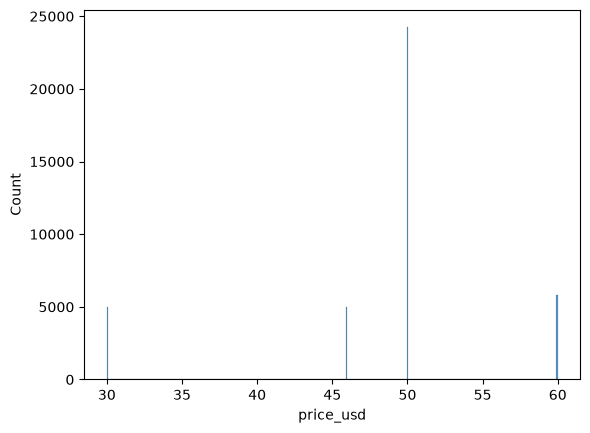

In [60]:
sns.histplot(df_order_items['price_usd'])

## Products Exploration

In [29]:
df_products = pd.read_csv('../data/products.csv')

In [30]:
df_products.shape

(4, 3)

In [31]:
df_products.head()

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [32]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    4 non-null      int64
 1   created_at    4 non-null      str  
 2   product_name  4 non-null      str  
dtypes: int64(1), str(2)
memory usage: 228.0 bytes


In [33]:
df_products['created_at'] = pd.to_datetime(df_products['created_at'])

In [34]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    4 non-null      int64         
 1   created_at    4 non-null      datetime64[us]
 2   product_name  4 non-null      str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 228.0 bytes


## Website Pageview Exploration|

In [35]:
df_page_view = pd.read_csv('../data/website_pageviews.csv')

In [36]:
df_page_view.shape

(1188124, 4)

In [37]:
df_page_view.head()

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


In [38]:
df_page_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   website_pageview_id  1188124 non-null  int64
 1   created_at           1188124 non-null  str  
 2   website_session_id   1188124 non-null  int64
 3   pageview_url         1188124 non-null  str  
dtypes: int64(2), str(2)
memory usage: 36.3 MB


In [39]:
df_page_view['created_at'] = pd.to_datetime(df_page_view['created_at'])

In [40]:
df_page_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   website_pageview_id  1188124 non-null  int64         
 1   created_at           1188124 non-null  datetime64[us]
 2   website_session_id   1188124 non-null  int64         
 3   pageview_url         1188124 non-null  str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 36.3 MB


In [63]:
df_page_view['created_at'].describe()

count                       1188124
mean     2014-03-14 05:47:55.608818
min             2012-03-19 08:04:16
25%      2013-09-09 18:11:12.250000
50%      2014-05-15 10:22:58.500000
75%      2014-11-13 13:43:46.500000
max             2015-03-19 07:59:32
Name: created_at, dtype: object

In [62]:
df_page_view['created_at'].dt.year.value_counts()

created_at
2014    597556
2013    278642
2015    175443
2012    136483
Name: count, dtype: int64

In [64]:
df_page_view['created_at'].dt.month.value_counts()

created_at
12    141319
11    131310
2     121172
1     120558
10    101052
3      98016
9      88280
8      85035
7      80294
5      75359
6      74332
4      71397
Name: count, dtype: int64

## Website Sessions Exploration

In [41]:
df_sessions = pd.read_csv('../data/website_sessions.csv')

In [42]:
df_sessions.shape

(472871, 9)

In [43]:
df_sessions.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [44]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   website_session_id  472871 non-null  int64
 1   created_at          472871 non-null  str  
 2   user_id             472871 non-null  int64
 3   is_repeat_session   472871 non-null  int64
 4   utm_source          389543 non-null  str  
 5   utm_campaign        389543 non-null  str  
 6   utm_content         389543 non-null  str  
 7   device_type         472871 non-null  str  
 8   http_referer        432954 non-null  str  
dtypes: int64(3), str(6)
memory usage: 32.5 MB


In [45]:
df_sessions['created_at'] = pd.to_datetime(df_sessions['created_at'])

In [46]:
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   website_session_id  472871 non-null  int64         
 1   created_at          472871 non-null  datetime64[us]
 2   user_id             472871 non-null  int64         
 3   is_repeat_session   472871 non-null  int64         
 4   utm_source          389543 non-null  str           
 5   utm_campaign        389543 non-null  str           
 6   utm_content         389543 non-null  str           
 7   device_type         472871 non-null  str           
 8   http_referer        432954 non-null  str           
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 32.5 MB


In [47]:
df_page_view['pageview_url'].value_counts()

pageview_url
/products                      261231
/the-original-mr-fuzzy         162525
/home                          137576
/lander-2                      131170
/cart                           94953
/lander-3                       79000
/lander-5                       68166
/shipping                       64484
/billing-2                      48441
/lander-1                       47574
/thank-you-for-your-order       32313
/the-forever-love-bear          26033
/the-birthday-sugar-panda       19046
/lander-4                        9385
/billing                         3617
/the-hudson-river-mini-bear      2610
Name: count, dtype: int64

In [65]:
df_website = df_page_view.merge(df_sessions, left_on='website_session_id', right_on='website_session_id', suffixes=['_pageview', '_session'])

In [66]:
df_website.head()

,website_pageview_id,created_at_pageview,website_session_id,pageview_url,created_at_session,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,/home,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,/home,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,/home,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,/home,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,/home,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [70]:
df_website[df_website['website_session_id'] == 20]

,website_pageview_id,created_at_pageview,website_session_id,pageview_url,created_at_session,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
29,30,2012-03-19 10:22:58,20,/home,2012-03-19 10:22:58,20,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
31,32,2012-03-19 10:28:09,20,/products,2012-03-19 10:22:58,20,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
32,33,2012-03-19 10:28:37,20,/the-original-mr-fuzzy,2012-03-19 10:22:58,20,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
33,34,2012-03-19 10:31:29,20,/cart,2012-03-19 10:22:58,20,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
34,35,2012-03-19 10:34:43,20,/shipping,2012-03-19 10:22:58,20,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
35,36,2012-03-19 10:36:31,20,/billing,2012-03-19 10:22:58,20,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
36,37,2012-03-19 10:42:46,20,/thank-you-for-your-order,2012-03-19 10:22:58,20,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com


In [69]:
df_website['website_session_id'].value_counts()

website_session_id
20        7
104       7
147       7
160       7
177       7
         ..
472854    1
472856    1
472862    1
472869    1
472871    1
Name: count, Length: 472871, dtype: int64